In [ ]:
# SINKHORN DIVERGENCE WORKING (Go for blur=1e-18 for basically Wasserstein I guees)

from geomloss import SamplesLoss
import torch
import time

## Sinkhorn distance
# 3. Computing the Sinkhorn Distances:
loss_fn = SamplesLoss(
    loss="sinkhorn", p=2, blur=1e9)

lengths = torch.linspace(100, 50000, 10, dtype=torch.int)
#lengths = [1000, 2000, 3000, 4000, 5000, 6000, 10000]
tot_time = 0
for N in lengths:
    pc1 = torch.rand((N, 3), device='cuda')
    pc0 = torch.rand((N, 3), device='cuda')

    start_time = time.time()
    distances = loss_fn(pc0, pc1)
    end_time = time.time()
    print(f"Time taken to compute Sinkhorn distances: {end_time - start_time:.4f} seconds at {N} pts")

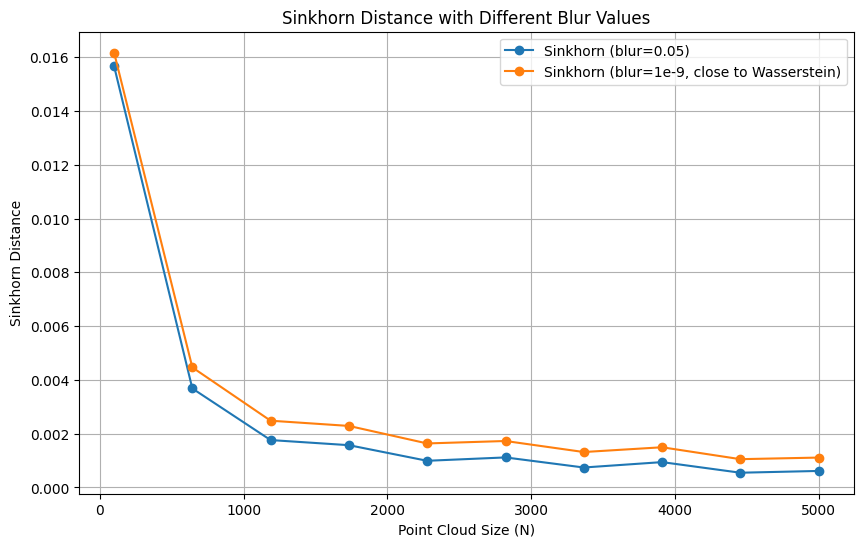

In [5]:
import matplotlib.pyplot as plt
from geomloss import SamplesLoss
import torch

# Define function to calculate Sinkhorn divergence
def compute_sinkhorn(pc0, pc1, blur=0.05):
    loss_fn = SamplesLoss(loss="sinkhorn", p=2, blur=blur)
    return loss_fn(pc0, pc1).item()

# Generate data
lengths = torch.linspace(100, 5000, 10, dtype=torch.int)
sinkhorn_blur_0_05 = []
sinkhorn_blur_0_1em9 = []

# Calculate Sinkhorn distances for two different blur values
for N in lengths:
    pc0 = torch.rand((N, 3), device="cuda")
    pc1 = torch.rand((N, 3), device="cuda")

    # With blur set to 0.05
    sinkhorn_blur_0_05.append(compute_sinkhorn(pc0, pc1, blur=0.05))

    # With blur set to 0.001 (closer to Wasserstein)
    sinkhorn_blur_0_1em9.append(compute_sinkhorn(pc0, pc1, blur=1e-9))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(lengths.cpu().numpy(), sinkhorn_blur_0_05, label="Sinkhorn (blur=0.05)", marker='o')
plt.plot(lengths.cpu().numpy(), sinkhorn_blur_0_1em9, label="Sinkhorn (blur=1e-9, close to Wasserstein)", marker='o')
plt.xlabel("Point Cloud Size (N)")
plt.ylabel("Sinkhorn Distance")
plt.title("Sinkhorn Distance with Different Blur Values")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pykeops
pykeops.test_numpy_bindings()    # perform the compilation

In [ ]:
import pykeops
pykeops.clean_pykeops()

In [ ]:
import torch
import ot
import time

# N = 
# pc0 = torch.rand((1000, 3), device="cuda")
# pc1 = torch.rand((1000, 3), device="cuda")

# # Convert to CPU and use OT solver with GPU-based tensors
# cost_matrix = torch.cdist(pc0, pc1).cpu().numpy()
# transport_plan = ot.emd([], [], cost_matrix)
# wasserstein_dist = (cost_matrix * transport_plan).sum()



lengths = torch.linspace(100, 30000, 10, dtype=torch.int)
#lengths = [1000, 2000, 3000, 4000, 5000, 6000]
tot_time = 0
for N in lengths:
    pc0 = torch.rand((N, 3), device="cuda")
    pc1 = torch.rand((N, 3), device="cuda")

    start_time = time.time()
    cost_matrix = torch.cdist(pc0, pc1).cpu().numpy()
    transport_plan = ot.emd([], [], cost_matrix)
    wasserstein_dist = (cost_matrix * transport_plan).sum()
    end_time = time.time()
    print(f"Time taken to compute EMD: {end_time - start_time:.4f} seconds at {N} pts")


In [ ]:
# CHAMFER DISTANCE WORKING

import torch
import time

def chamfer_distance(pc0, pc1):
    # Compute pairwise distances
    dist_pc0_pc1 = torch.cdist(pc0, pc1)  # Shape: [N, M]

    # Minimum distance from each point in pc0 to any point in pc1
    min_dist_pc0_pc1 = dist_pc0_pc1.min(dim=1).values

    # Minimum distance from each point in pc1 to any point in pc0
    min_dist_pc1_pc0 = dist_pc0_pc1.min(dim=0).values
    del dist_pc0_pc1

    # Chamfer distance is the sum of minimum distances
    chamfer_dist = min_dist_pc0_pc1.mean() + min_dist_pc1_pc0.mean()
    return chamfer_dist

N = 35000
pc0 = torch.rand((N, 3), device="cuda")
pc1 = torch.rand((N, 3), device="cuda")

start_time = time.time()
dist = chamfer_distance(pc0, pc1)
end_time = time.time()
print(f"Time taken to compute Chamfer distances: {end_time - start_time:.4f} seconds at {N} pts")


In [ ]:
import torch
import time

def hausdorff_distance(pc0, pc1):
    # Compute pairwise distances
    dist_pc0_pc1 = torch.cdist(pc0, pc1)  # Shape: [N, M]

    # Minimum distance from each point in pc0 to any point in pc1
    min_dist_pc0_pc1 = dist_pc0_pc1.min(dim=1).values

    # Minimum distance from each point in pc1 to any point in pc0
    min_dist_pc1_pc0 = dist_pc0_pc1.min(dim=0).values
    del dist_pc0_pc1

    # Hausdorff distance is the maximum of these minimum distances in both directions
    hausdorff_dist = torch.max(min_dist_pc0_pc1.max(), min_dist_pc1_pc0.max())
    return hausdorff_dist

# Testing the function
N = 35000
pc0 = torch.rand((N, 3), device="cuda")
pc1 = torch.rand((N, 3), device="cuda")

start_time = time.time()
dist = hausdorff_distance(pc0, pc1)
end_time = time.time()
print(f"Hausdorff distance: {dist.item():.4f}")
print(f"Time taken to compute Hausdorff distance: {end_time - start_time:.4f} seconds at {N} pts")


In [ ]:
## Plots with random data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generating random data for demonstration
np.random.seed(42)
num_samples = 200

# Simulated class labels (0 to 4)
gt_labels = np.random.choice([0, 1, 2, 3, 4], size=num_samples)

# Simulated metrics with some variability per class
data = {
    "GT_Label": gt_labels,
    "Mean_Map_Entropy": np.random.normal(0.5 + gt_labels * 0.1, 0.1, num_samples),
    "Chamfer_Distance": np.random.normal(0.3 + gt_labels * 0.15, 0.1, num_samples),
    "Earth_Movers_Distance": np.random.normal(0.4 + gt_labels * 0.12, 0.1, num_samples),
    "Hausdorff_Distance": np.random.normal(0.6 + gt_labels * 0.2, 0.15, num_samples),
}

df = pd.DataFrame(data)

# Set up the figure
plt.figure(figsize=(15, 10))

# Plotting each metric as a box plot by class label
metrics = ["Mean_Map_Entropy", "Chamfer_Distance", "Earth_Movers_Distance", "Hausdorff_Distance"]
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="GT_Label", y=metric, data=df)
    plt.title(f'{metric} by GT_Label')
    plt.xlabel('GT_Label (Alignment Level)')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()

# Set up the figure
plt.figure(figsize=(15, 10))

# Plotting each metric as a violin plot by class label
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x="GT_Label", y=metric, data=df, inner="box")
    plt.title(f'{metric} by GT_Label')
    plt.xlabel('GT_Label (Alignment Level)')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


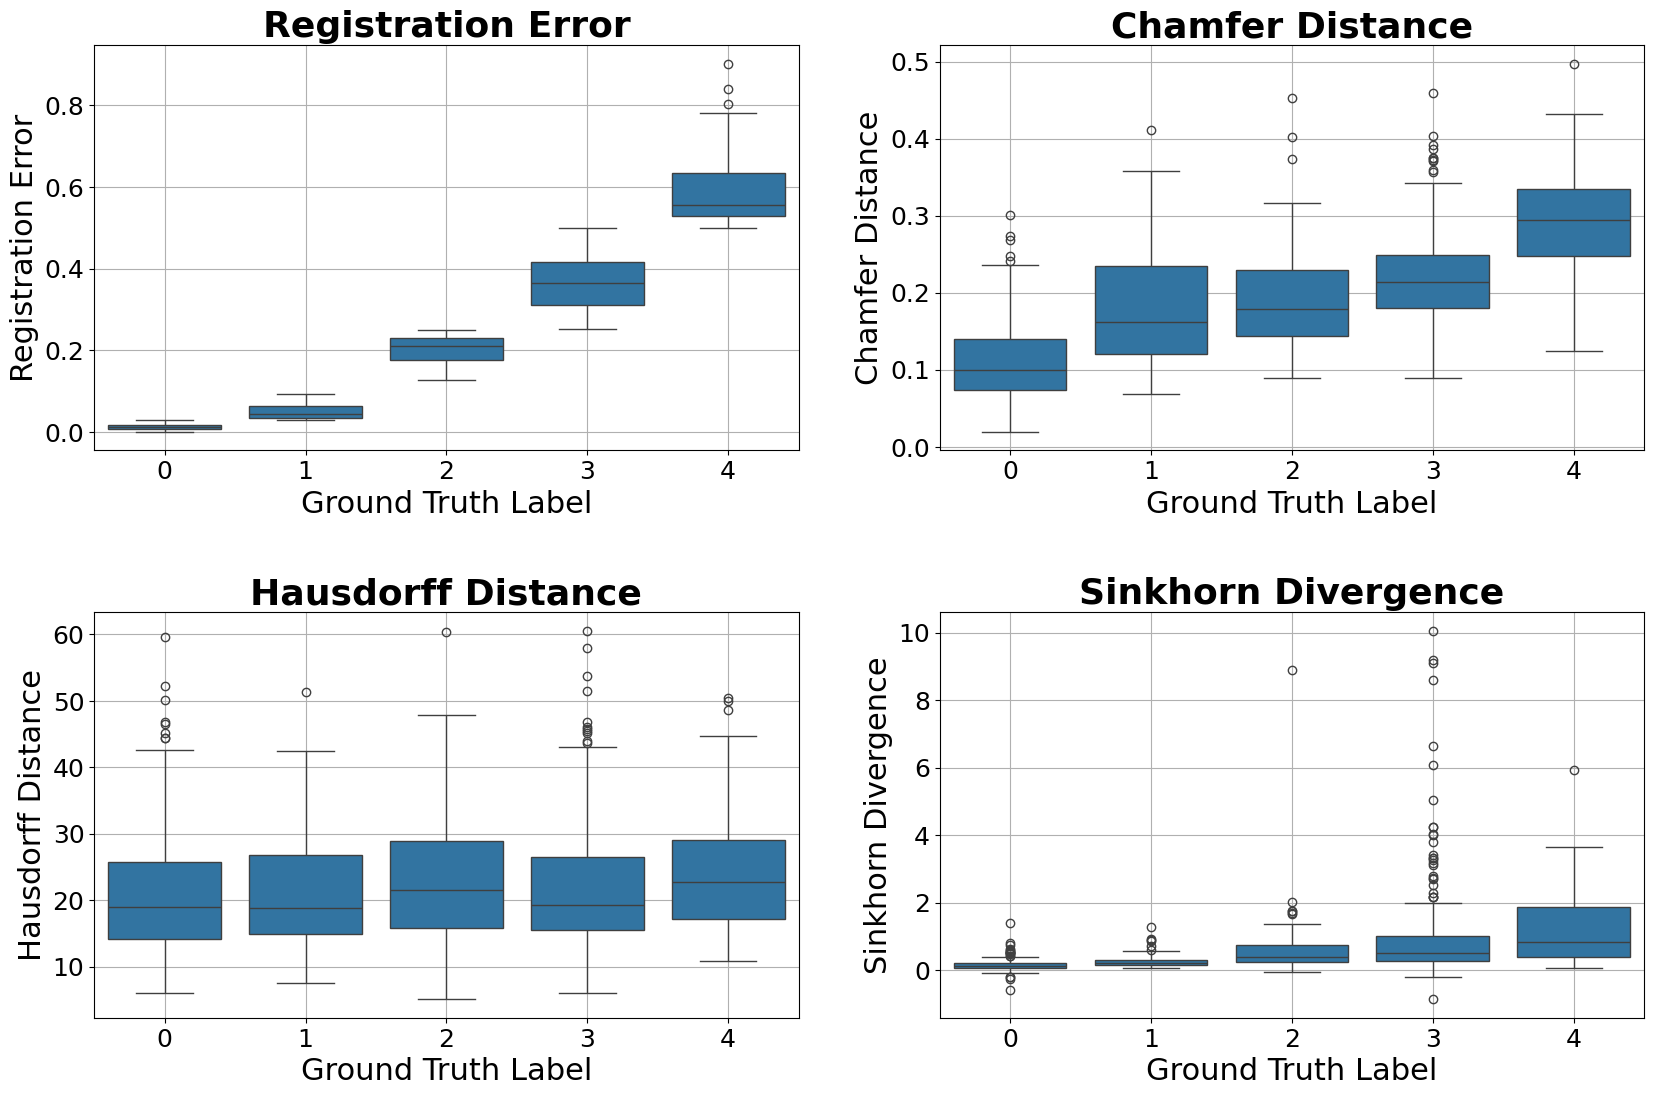

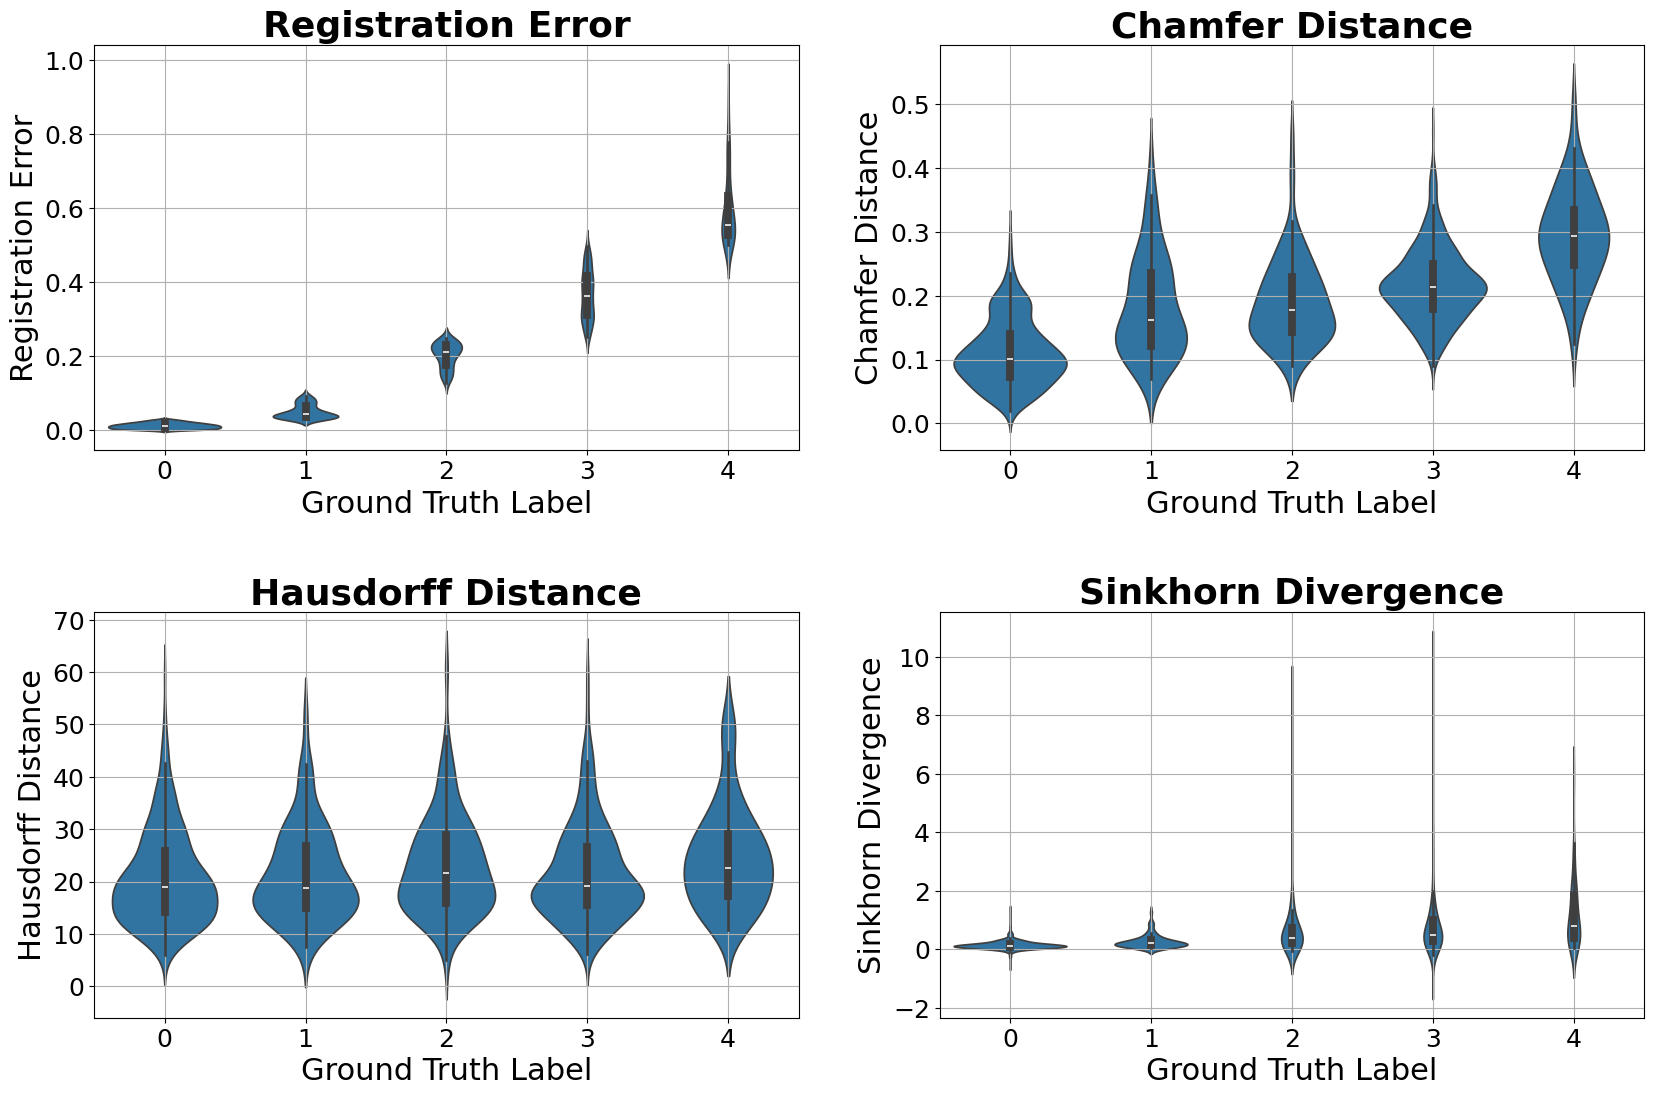

In [23]:
path = "/home/lu2277di/Projects/FACT/images/classification/PointTransformer/metrics_vs_gt_class/metrics_data_20241112_173658_metrics_vs_gts_n_samples850.txt"

# Loading the data from file as per the user's previous file format
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data from text file
data = np.loadtxt(path, delimiter="\t", skiprows=1)

# Extracting individual columns
reg_error = data[:, 0]
hausdorff_distances = data[:, 1]
chamfer_distances = data[:, 2]
sinkhorn_distances_0_05 = data[:, 3]
sinkhorn_distances_1em9 = data[:, 4]
gt_labels = data[:, 5].astype(int)  # Assuming GT values are integers

# Creating a DataFrame
df = pd.DataFrame({
    "Ground Truth Label": gt_labels,
    "Registration Error": reg_error,
    "Chamfer Distance": chamfer_distances,
    "Hausdorff Distance": hausdorff_distances,
    "Sinkhorn Divergence": sinkhorn_distances_0_05,
    #"Sinkhorn_Distance_1e-9": sinkhorn_distances_1em9,
})

class_counts = df["Ground Truth Label"].value_counts().sort_index()


# Define the list of metrics for plotting#
metrics = ["Registration Error", "Chamfer Distance", "Hausdorff Distance", "Sinkhorn Divergence", "Sinkhorn_Distance_1e-9"]
metrics = [metric for metric in metrics if metric in df.columns]

# for metric in metrics:
#     lower_limit = df[metric].quantile(0.025)  # 5th percentile
#     upper_limit = df[metric].quantile(0.975)  # 95th percentile
#     df = df[(df[metric] >= lower_limit) & (df[metric] <= upper_limit)]

directory = "/home/lu2277di/Projects/FACT/images/classification/PointTransformer/metrics_vs_gt_class/"

# Plotting each metric as a box plot by GT_Label
for j in range(2):
    plt.figure(figsize=(20, 20))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(3, 2, i)  # Adjusting to fit all metrics in a grid
        if j == 0:
            sns.boxplot(x="Ground Truth Label", y=metric, data=df)
            plot_type = "boxplot"
        else:
            sns.violinplot(x="Ground Truth Label", y=metric, data=df, inner="box")
            plot_type = "violinplot"

        # # Add the sample counts as text above each class on the x-axis
        # for x, count in class_counts.items():
        #     plt.text(x, df[metric].max(), f'n={count}', 
        #              ha='center', va='bottom', fontweight='bold', fontsize=10, color="black")


        plt.title(f'{metric}', fontsize=26, fontweight='bold')
        plt.xlabel('Ground Truth Label', fontsize=22)
        plt.ylabel(metric, fontsize=22)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid()


    plt.subplots_adjust(wspace=0.2, hspace=0.4)  # Adjust wspace and hspace as needed

    # Save the figure in both .eps and .jpg formats
    filename = f"{directory}/{plot_type}_with_outliers_bold_title_v5"
    #plt.savefig(f"{filename}.eps", format="eps")
    #plt.savefig(f"{filename}.jpg", format="jpg", dpi=300)  # Use dpi=300 for high quality



    #plt.tight_layout()
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


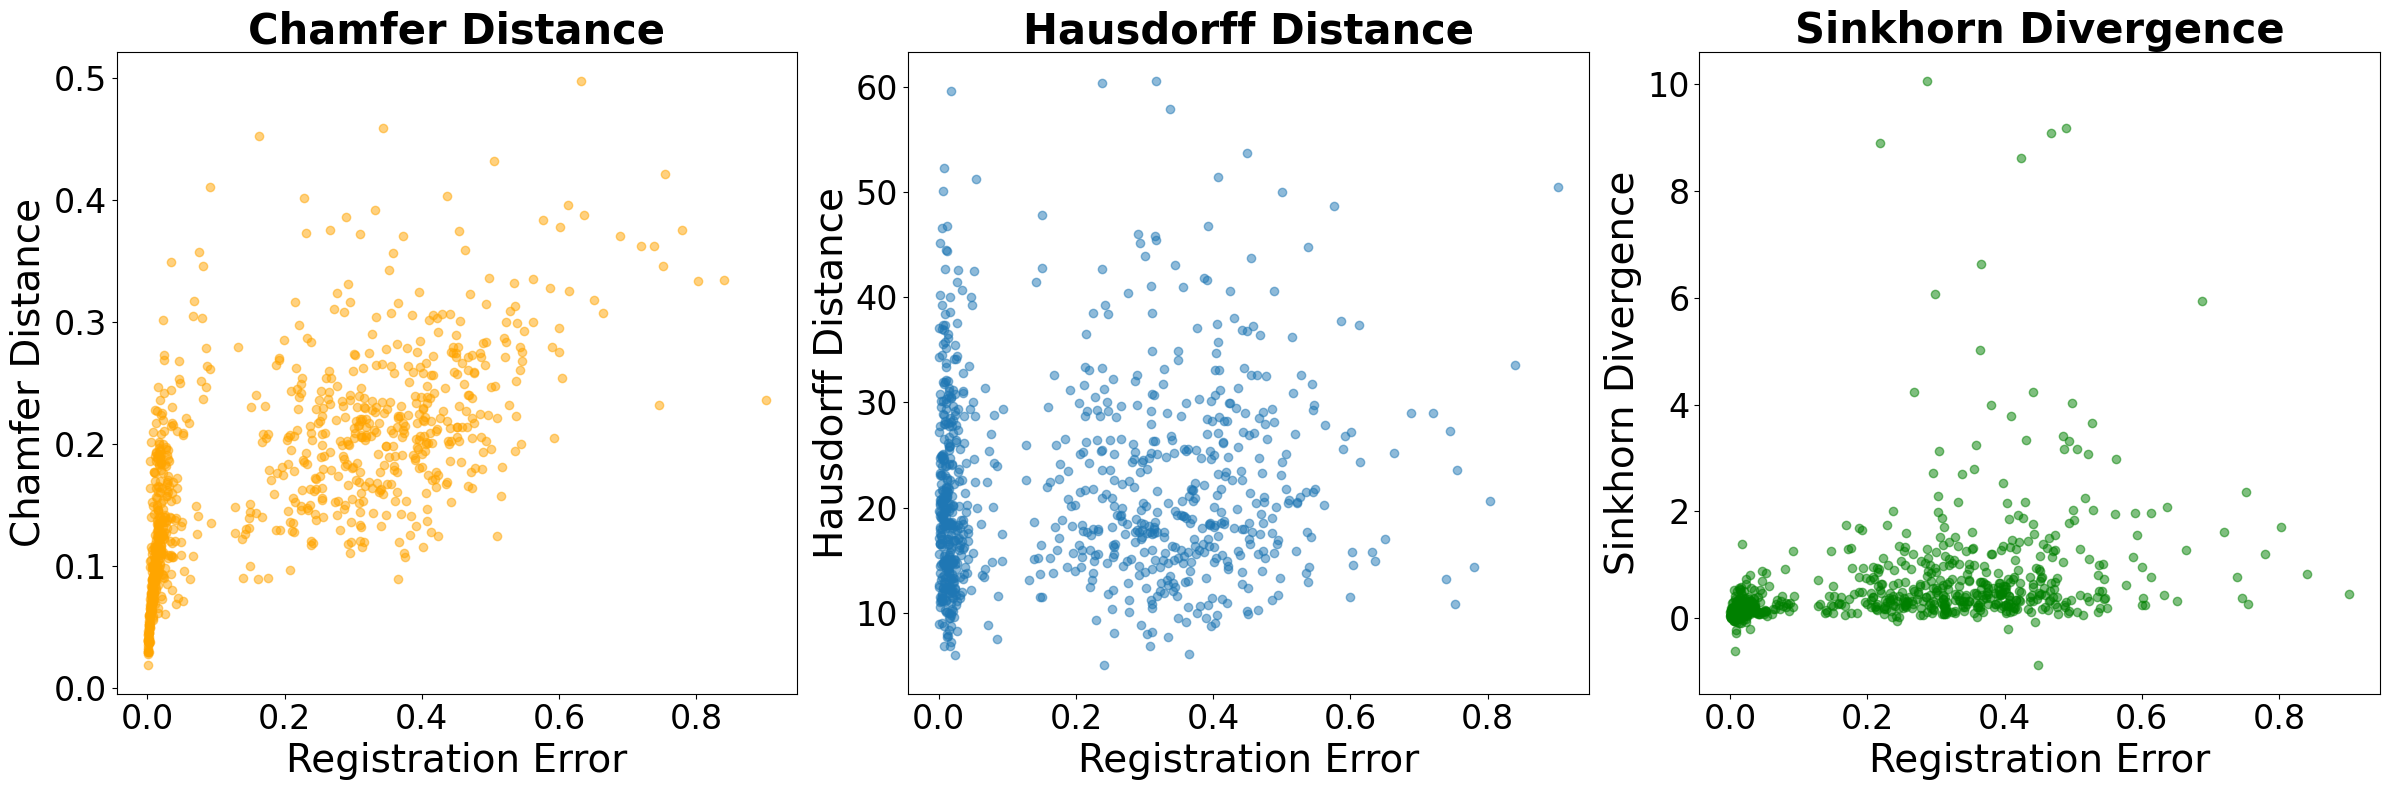

In [15]:
path = "/home/lu2277di/Projects/FACT/images/classification/PointTransformer/metrics_vs_gt_class/metrics_data_20241112_173658_metrics_vs_gts_n_samples850.txt"

# Loading the data from file as per the user's previous file format
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data from text file
data = np.loadtxt(path, delimiter="\t", skiprows=1)

# Extracting individual columns
reg_error = data[:, 0]
hausdorff_distances = data[:, 1]
chamfer_distances = data[:, 2]
sinkhorn_distances_0_05 = data[:, 3]
sinkhorn_distances_1em9 = data[:, 4]
gt_labels = data[:, 5].astype(int)  # Assuming GT values are integers

# Creating a DataFrame
df = pd.DataFrame({
    "Ground Truth Label": gt_labels,
    "Point Transformation Error": reg_error,
    "Chamfer Distance": chamfer_distances,
    "Hausdorff Distance": hausdorff_distances,
    "Sinkhorn Divergence": sinkhorn_distances_0_05,
    #"Sinkhorn_Distance_1e-9": sinkhorn_distances_1em9,
})

class_counts = df["Ground Truth Label"].value_counts().sort_index()


# Define the list of metrics for plotting#
metrics = ["Point Transformation Error", "Chamfer Distance", "Hausdorff Distance", "Sinkhorn Divergence", "Sinkhorn_Distance_1e-9"]
metrics = [metric for metric in metrics if metric in df.columns]

# for metric in metrics:
#     lower_limit = df[metric].quantile(0.025)  # 5th percentile
#     upper_limit = df[metric].quantile(0.975)  # 95th percentile
#     df = df[(df[metric] >= lower_limit) & (df[metric] <= upper_limit)]


# Create 2x2 subplots
fig, axs = plt.subplots(1, 3, figsize=(24, 8))
reg_error_in = reg_error.flatten()
# Plot Hausdorff distance vs. registration error
# axs[0].scatter(reg_error_in, hausdorff_distances, alpha=0.5)
# axs[0].set_title("Hausdorff Distance vs Registration Error")
# axs[0].set_xlabel("Registration Error")
# axs[0].set_ylabel("Hausdorff Distance")

# # Plot Chamfer distance vs. registration error
# axs[1].scatter(reg_error_in, chamfer_distances, alpha=0.5, color='orange')
# axs[1].set_title("Chamfer Distance vs Registration Error")
# axs[1].set_xlabel("Registration Error")
# axs[1].set_ylabel("Chamfer Distance")

# # Plot Sinkhorn distance (blur=0.05) vs. registration error
# axs[2].scatter(reg_error_in, sinkhorn_distances_0_05, alpha=0.5, color='green')
# axs[2].set_title("Sinkhorn Divergence vs Registration Error")
# axs[2].set_xlabel("Registration Error")
# axs[2].set_ylabel("Sinkhorn Distance")

# Set the font sizes
title_fontsize = 30
label_fontsize = 28
tick_fontsize = 24

# Plot Hausdorff distance vs. registration error
axs[1].scatter(reg_error_in, hausdorff_distances.flatten(), alpha=0.5)
axs[1].set_title("Hausdorff Distance", fontsize=title_fontsize, weight='bold')
axs[1].set_xlabel("Registration Error", fontsize=label_fontsize)
axs[1].set_ylabel("Hausdorff Distance", fontsize=label_fontsize)
axs[1].tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Plot Chamfer distance vs. registration error
axs[0].scatter(reg_error_in, chamfer_distances.flatten(), alpha=0.5, color='orange')
axs[0].set_title("Chamfer Distance", fontsize=title_fontsize, weight='bold')
axs[0].set_xlabel("Registration Error", fontsize=label_fontsize)
axs[0].set_ylabel("Chamfer Distance", fontsize=label_fontsize)
axs[0].tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Plot Sinkhorn distance (blur=0.05) vs. registration error
axs[2].scatter(reg_error_in, sinkhorn_distances_0_05.flatten(), alpha=0.5, color='green')
axs[2].set_title("Sinkhorn Divergence", fontsize=title_fontsize, weight='bold')
axs[2].set_xlabel("Registration Error", fontsize=label_fontsize)
axs[2].set_ylabel("Sinkhorn Divergence", fontsize=label_fontsize)
axs[2].tick_params(axis='both', which='major', labelsize=tick_fontsize)



# Adjust layout
plt.tight_layout()



directory = "/home/lu2277di/Projects/FACT/images/classification/PointTransformer/metrics_vs_gt_class/"
file_name = f"metrics_vs_registration_error_scatter_plots_bold_font_v3"

# # Save the figure to an .eps file
fig.savefig(f"{directory}/{file_name}.eps", format="eps", bbox_inches='tight')
# # Save the figure to an .jpg file
fig.savefig(f"{directory}/{file_name}.jpg", format="jpg", bbox_inches='tight')

plt.show()